This Notebook is me trying to understand how `fftconvolve` works in numpy. I a trying to reproduce it exactly.

In [3]:
from oakley import *
Message.go_root()
from src.mirix_grids import *

[#] Current working directory: /home/jwehrung/Documents/code/miriX/mirix_grids
Environment variables set!


In [57]:
mxgrid = MirixGrid("src/mirix_grids/data/grid_filter-F1140C_nlambda-1_oversample-4_date-2023-09-04_psfshape-183_gridshape-272_psfoversample-2_pca_k-200.fits", pca_k=1)

[~] Loading grid (0.814s)
[i] Grid metadata:
 > filter:         F1140C
 > nlambda:        1
 > oversample:     4
 > date:           2023-09-04
 > psf_shape:      183
 > gridsize:       272
 > psf_oversample: 2
 > pca_k:          200
[i] Data shapes:
 > components:      (200, 183, 183)
 > coefficients:    (73984, 200)
 > singular_values: (200,)
 > xgrid:           (73984,)
 > ygrid:           (73984,)
[i] Data shapes after reshape:
 > components:   (1, 183, 183)
 > coefficients: (272, 272, 1)
 > xgrid:        (272, 272)
 > ygrid:        (272, 272)


In [78]:
mxgrid.components.shape

(1, 183, 183)

array([[1.0057902, 1.0061781, 1.0065154, ..., 1.0017878, 1.0013052,
        1.0007594],
       [1.005814 , 1.0062116, 1.0065645, ..., 1.0018839, 1.0014033,
        1.0008596],
       [1.0057524, 1.0061555, 1.0065204, ..., 1.0018734, 1.0013931,
        1.0008509],
       ...,
       [1.0011717, 1.0017506, 1.0022712, ..., 1.0064061, 1.0060843,
        1.0057163],
       [1.001111 , 1.001691 , 1.0022105, ..., 1.006404 , 1.0060923,
        1.0057293],
       [1.0009509, 1.0015341, 1.0020567, ..., 1.0063184, 1.0060216,
        1.0056663]], shape=(272, 272), dtype=float32)

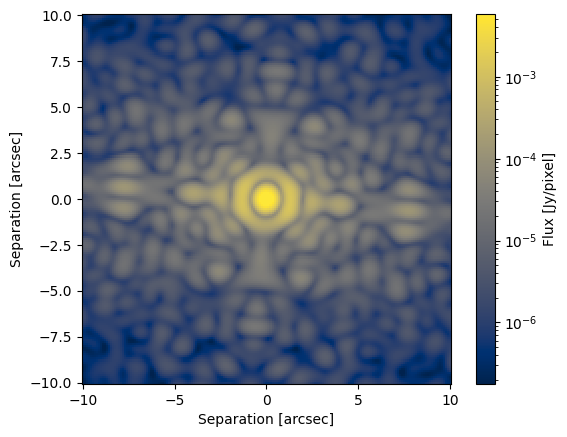

In [60]:
# 1. Let's take the first PSF component
kernel = mxgrid.components[0]
# remove the bottom left corner of this kernel to make it more interesting
#kernel[:len(kernel) // 2, :len(kernel) // 2] = 0
from xrdi_toolkit import *
plot_image2d(kernel)

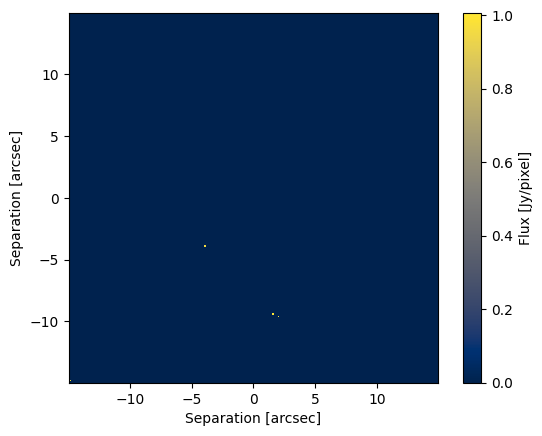

In [82]:
# build some diracs
dirac0 = mxgrid.dirac(i=1, j=1)
dirac1 = mxgrid.dirac(i=100, j=100)
dirac2 = mxgrid.dirac(i=150, j=50)
dirac3 = mxgrid.dirac(i=154, j=48)
dirac = dirac0 + dirac1 + dirac2 + dirac3
dirac = dirac

plot_image2d(dirac, qmax=1, qmin=0)

[~] Propagating image... (0.002s)


[~] Propagating image... (0.002s)


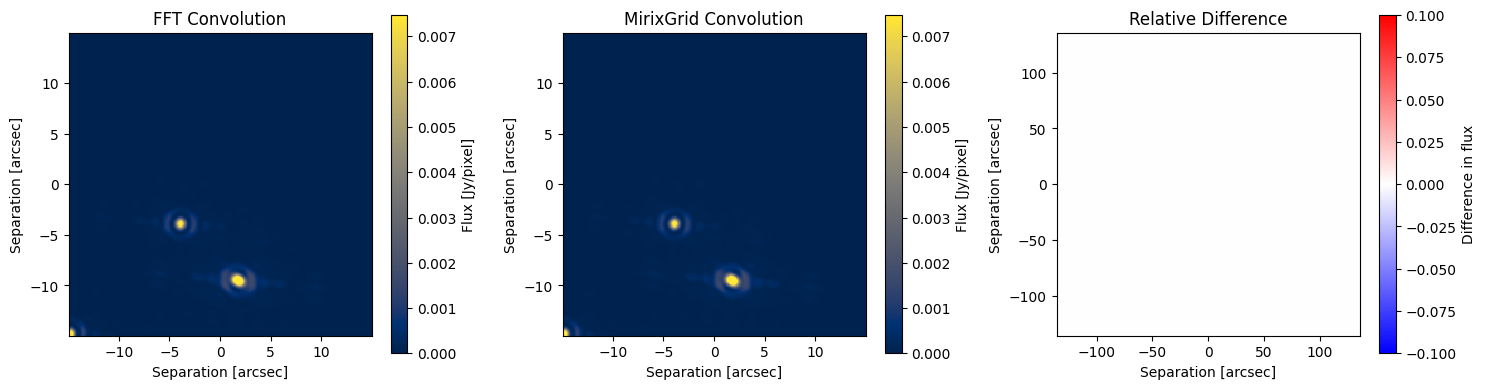

In [84]:
# let's convole!
from scipy.signal import fftconvolve
import numpy as np
image = fftconvolve(dirac * mxgrid.coefficients[:, :, 0], kernel, mode="same")
image_mxgrid = mxgrid.forward(dirac)
difference = (image - image_mxgrid) / np.max(image_mxgrid)

import matplotlib.pyplot as plt
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.title("FFT Convolution")
plot_image2d(image)
plt.subplot(1, 3, 2)
plt.title("MirixGrid Convolution")
plot_image2d(image_mxgrid)
plt.subplot(1, 3, 3)
plt.title("Relative Difference")
plot_image2d(difference, qmax=1, qmin=0, colormap="bwr", colorbar_label="Difference in flux", pixel_scale_arcsec=1)
plt.tight_layout()
plt.show()

Let's try to get that back myself!

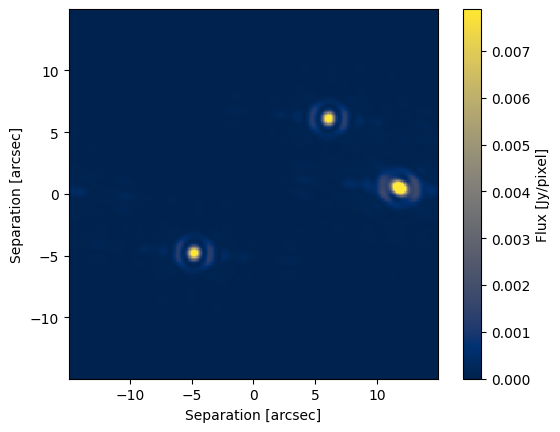

[~] Convolving with FFT (0.076s)
[~] Convolving with FFT (mxgrid) (0.049s)


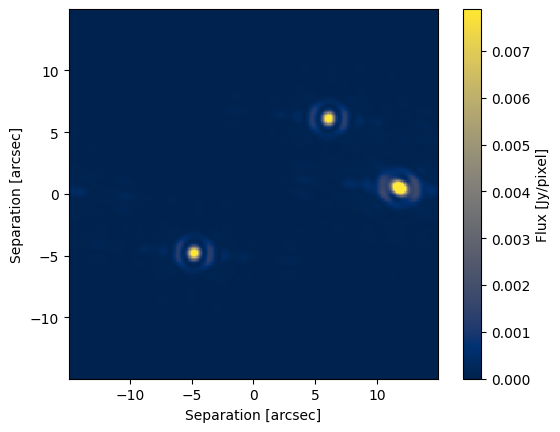

[~] Convolving with FFT (0.076s)
[~] Convolving with FFT (mxgrid) (0.049s)


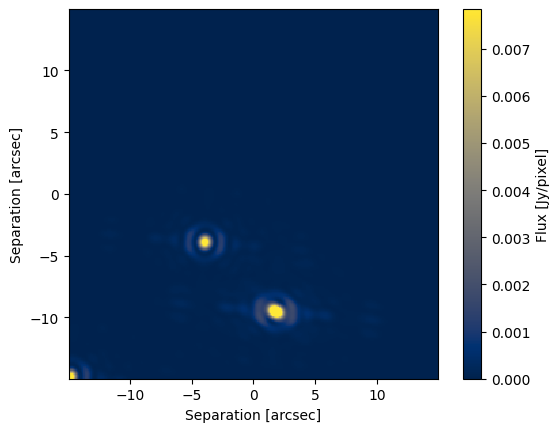

In [73]:
from scipy.fft import fft2, ifft2, fftshift, next_fast_len
import numpy as np
import matplotlib.pyplot as plt

def fftconvole_test1(image, kernal):
    F_image = fft2(image)
    F_kernal = fft2(kernal, s=image.shape)
    F_convolved = F_image * F_kernal
    convolved = ifft2(F_convolved)
    return np.real(convolved)


test_output = fftconvole_test1(dirac, kernel)
plot_image2d(test_output)
plt.show()

def _centered(arr: np.ndarray, newshape: tuple[int, int]) -> np.ndarray:
    """
    Return the centered portion of arr with shape newshape.
    Matches scipy.signal._centered.
    """
    currshape = np.array(arr.shape)
    newshape = np.array(newshape)
    startind = (currshape - newshape) // 2
    endind = startind + newshape
    return arr[startind[0]:endind[0], startind[1]:endind[1]]

def fftconvole_test2(image, kernal):    
    s1 = np.array(image.shape)
    s2 = np.array(kernal.shape)
    shape = tuple(s1 + s2 - 1)
    
    # pad to fft friendly size
    fshape = tuple(next_fast_len(s) for s in shape)
       
    
    sp1 = fft2(image, s=fshape)
    sp2 = fft2(kernal, s=fshape)
    ret = ifft2(sp1 * sp2, s=fshape)
    ret = ret[:shape[0], :shape[1]] # remove padding
    
    # crop to output shape
    ret = _centered(ret, s1)
    
    return np.real(ret)

with Task("Convolving with FFT"):
    for i in range(20):
        test_output2 = fftconvole_test2(dirac, kernel)
with Task("Convolving with FFT (mxgrid)"):
    with Message.mute():
        for i in range(20):
            test_output3 = mxgrid.forward(dirac)
        
plot_image2d(test_output2)
plt.show()
    

Relative difference: 9.2216839042689e-08


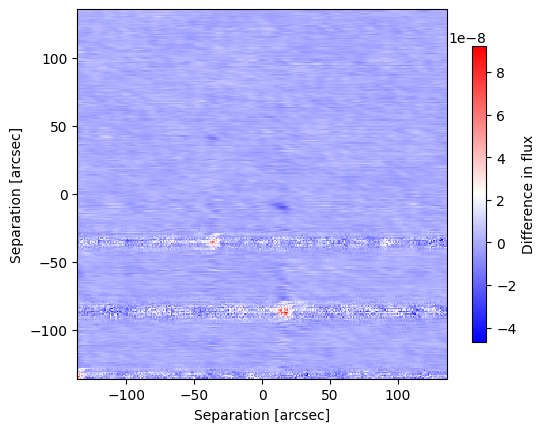

In [68]:
# compare the two outputs
difference = (image - test_output2) / np.max(image)
plot_image2d(
    difference,
    qmax=1,
    qmin=0,
    log_scale=False,
    colormap="bwr",
    colorbar_shrink=0.8,
    colorbar_label="Difference in flux",
    pixel_scale_arcsec=1,
)

print("Relative difference:", np.max(np.abs(difference)))

[~] Propagating image... (0.002s)
[~] Propagating image... (0.002s)
Stripe metric pure_conv           : 9.552264501028878e-05
Stripe metric forward center delta: 4.730343532309447e-08
Stripe metric forward edge delta  : 8.344474153533945e-05
Coeff0 range: 0.0004729804932139814 1.0221294164657593
Coeff0 stripe metric: 0.2620055079460144


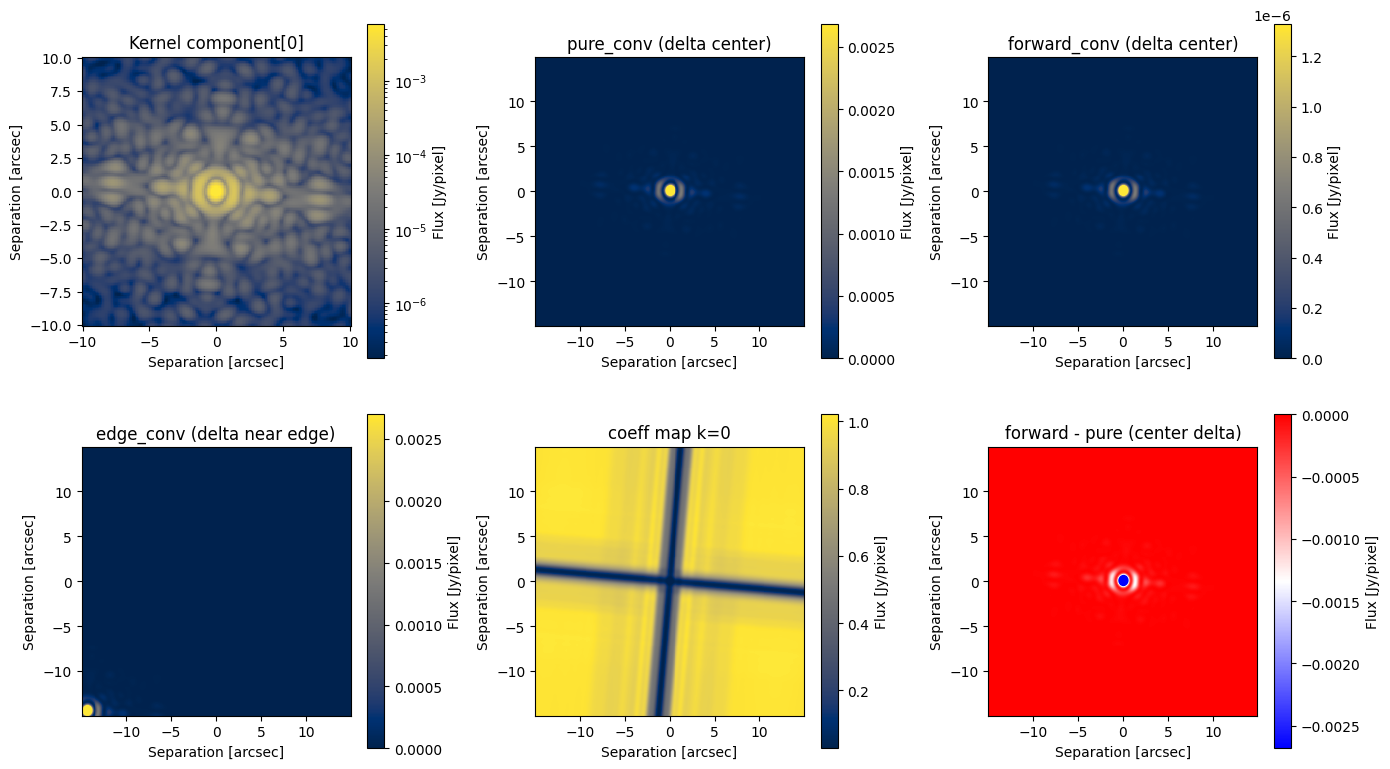

In [85]:
# Artifact diagnostics: isolate source of horizontal/vertical line patterns
from scipy.signal import fftconvolve
import numpy as np
import matplotlib.pyplot as plt

# 1) Pure kernel test (no coefficient map): delta at center
ny, nx = mxgrid.shape
delta_center = np.zeros((ny, nx), dtype=float)
delta_center[ny // 2, nx // 2] = 1.0
pure_conv = fftconvolve(delta_center, mxgrid.components[0], mode='same')

# 2) Forward test with same delta (includes coefficient map weighting)
forward_conv = mxgrid.forward(delta_center)

# 3) Boundary stress test: delta near edge (checks zero-padding / edge ringing)
delta_edge = np.zeros((ny, nx), dtype=float)
delta_edge[5, 5] = 1.0
edge_conv = mxgrid.forward(delta_edge)

# Row/column stripe metric: std of row means + std of col means
# Large values indicate horizontal/vertical striping in background.
def stripe_metric(img):
    row_m = img.mean(axis=1)
    col_m = img.mean(axis=0)
    return float(np.std(row_m) + np.std(col_m))

print('Stripe metric pure_conv           :', stripe_metric(pure_conv))
print('Stripe metric forward center delta:', stripe_metric(forward_conv))
print('Stripe metric forward edge delta  :', stripe_metric(edge_conv))

# Inspect coefficient map itself for grid-like structure
coeff0 = mxgrid.coefficients[:, :, 0]
print('Coeff0 range:', float(coeff0.min()), float(coeff0.max()))
print('Coeff0 stripe metric:', stripe_metric(coeff0))

plt.figure(figsize=(14, 8))
plt.subplot(2, 3, 1)
plt.title('Kernel component[0]')
plot_image2d(mxgrid.components[0])

plt.subplot(2, 3, 2)
plt.title('pure_conv (delta center)')
plot_image2d(pure_conv)

plt.subplot(2, 3, 3)
plt.title('forward_conv (delta center)')
plot_image2d(forward_conv)

plt.subplot(2, 3, 4)
plt.title('edge_conv (delta near edge)')
plot_image2d(edge_conv)

plt.subplot(2, 3, 5)
plt.title('coeff map k=0')
plot_image2d(coeff0)

plt.subplot(2, 3, 6)
plt.title('forward - pure (center delta)')
plot_image2d(forward_conv - pure_conv, colormap='bwr')
plt.tight_layout()
plt.show()

[~] Loading grid (0.776s)
[i] Grid metadata:
 > filter:         F1140C
 > nlambda:        1
 > oversample:     4
 > date:           2023-09-04
 > psf_shape:      183
 > gridsize:       272
 > psf_oversample: 2
 > pca_k:          200
[i] Data shapes:
 > components:      (200, 183, 183)
 > coefficients:    (73984, 200)
 > singular_values: (200,)
 > xgrid:           (73984,)
 > ygrid:           (73984,)
[i] Data shapes after reshape:
 > components:   (1, 183, 183)
 > coefficients: (272, 272, 1)
 > xgrid:        (272, 272)
 > ygrid:        (272, 272)
[~] Loading grid (0.787s)
[i] Grid metadata:
 > filter:         F1140C
 > nlambda:        1
 > oversample:     4
 > date:           2023-09-04
 > psf_shape:      183
 > gridsize:       272
 > psf_oversample: 2
 > pca_k:          200
[i] Data shapes:
 > components:      (200, 183, 183)
 > coefficients:    (73984, 200)
 > singular_values: (200,)
 > xgrid:           (73984,)
 > ygrid:           (73984,)
[i] Data shapes after reshape:
 > component

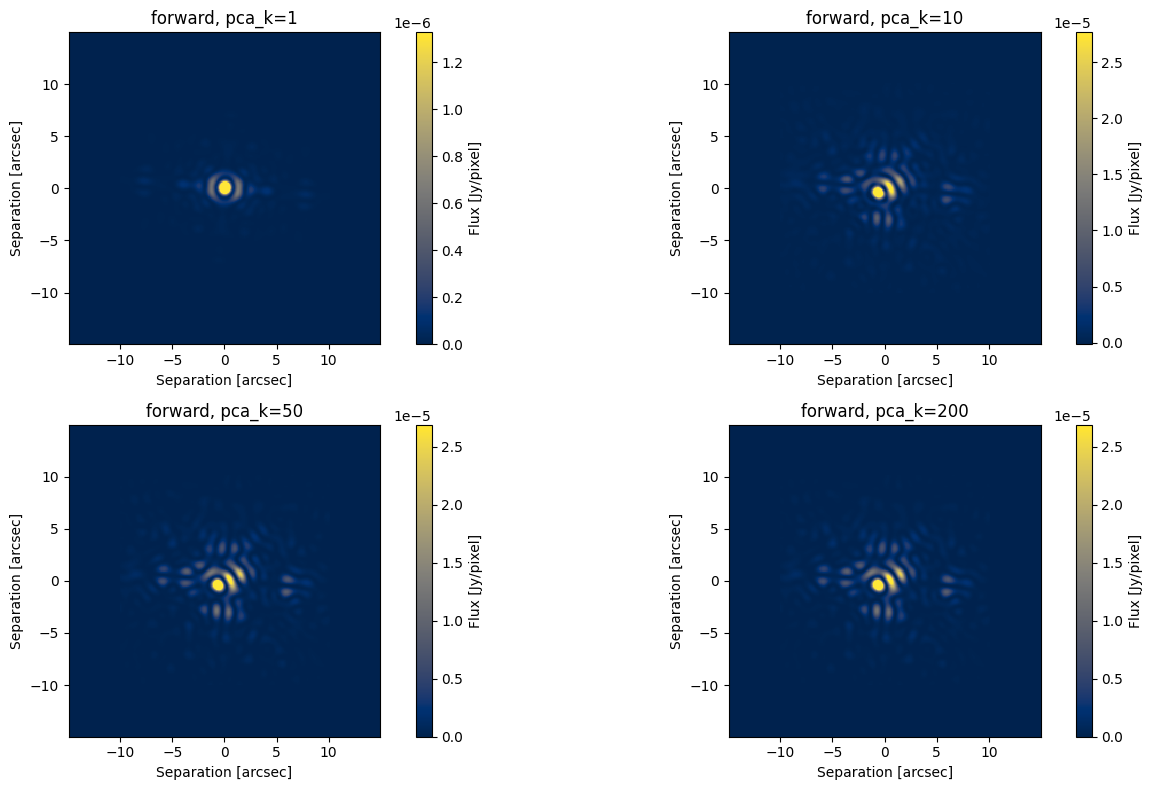

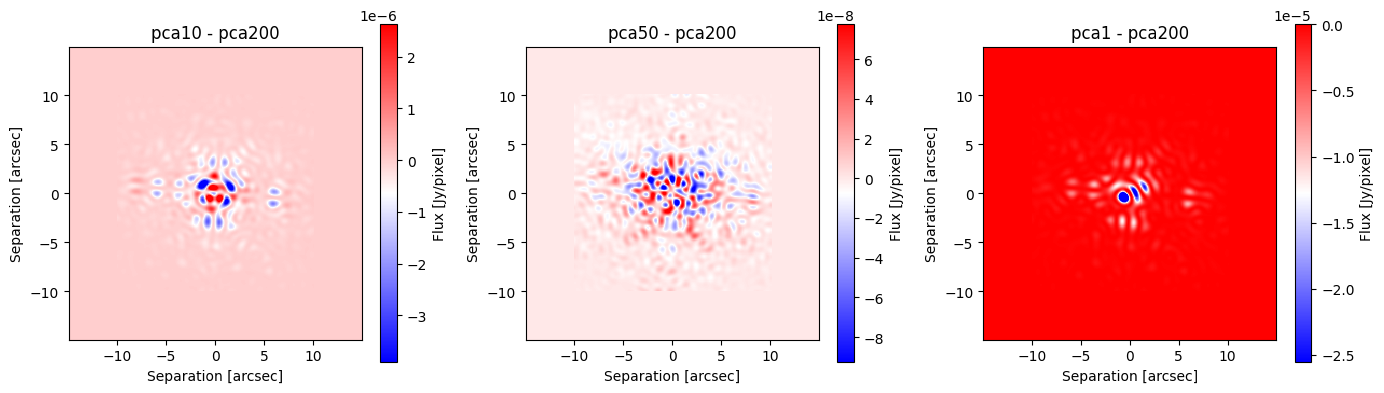

In [86]:
# Check whether the cross artifact shrinks when using more PCA components
filepath = "src/mirix_grids/data/grid_filter-F1140C_nlambda-1_oversample-4_date-2023-09-04_psfshape-183_gridshape-272_psfoversample-2_pca_k-200.fits"
mx1 = MirixGrid(filepath, pca_k=1)
mx10 = MirixGrid(filepath, pca_k=10)
mx50 = MirixGrid(filepath, pca_k=50)
mx200 = MirixGrid(filepath, pca_k=200)

ny, nx = mx1.shape
delta_center = np.zeros((ny, nx), dtype=float)
delta_center[ny // 2, nx // 2] = 1.0

img1 = mx1.forward(delta_center)
img10 = mx10.forward(delta_center)
img50 = mx50.forward(delta_center)
img200 = mx200.forward(delta_center)

def stripe_metric(img):
    row_m = img.mean(axis=1)
    col_m = img.mean(axis=0)
    return float(np.std(row_m) + np.std(col_m))

print('stripe metric pca_k=1  :', stripe_metric(img1))
print('stripe metric pca_k=10 :', stripe_metric(img10))
print('stripe metric pca_k=50 :', stripe_metric(img50))
print('stripe metric pca_k=200:', stripe_metric(img200))

plt.figure(figsize=(14, 8))
for idx, (im, title) in enumerate([
    (img1, 'forward, pca_k=1'),
    (img10, 'forward, pca_k=10'),
    (img50, 'forward, pca_k=50'),
    (img200, 'forward, pca_k=200'),
], start=1):
    plt.subplot(2, 2, idx)
    plt.title(title)
    plot_image2d(im)

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.title('pca10 - pca200')
plot_image2d(img10 - img200, colormap='bwr')
plt.subplot(1, 3, 2)
plt.title('pca50 - pca200')
plot_image2d(img50 - img200, colormap='bwr')
plt.subplot(1, 3, 3)
plt.title('pca1 - pca200')
plot_image2d(img1 - img200, colormap='bwr')
plt.tight_layout()
plt.show()